## EKF: Mass–Spring–Damper

### Continuous‐Time Physics Derivation

Newton’s second law with an external force $u(t)$ gives  
$$
m\,\ddot x(t) + c\,\dot x(t) + k\,x(t) = u(t).
$$  
Define  
$$
x(t) =
\begin{bmatrix}
x_1(t) \\[4pt]
x_2(t)
\end{bmatrix}
=
\begin{bmatrix}
x(t) \\[4pt]
\dot x(t)
\end{bmatrix}, 
\quad
F = 
\begin{bmatrix}
0 & 1 \\[4pt]
-\tfrac{k}{m} & -\tfrac{c}{m}
\end{bmatrix},
\quad
G = 
\begin{bmatrix}
0 \\[4pt]
\tfrac{1}{m}
\end{bmatrix}.
$$  
Then the continuous‐time state‐space with noise and input is  

$$
\boxed{
\begin{aligned}
\dot x(t) &= F\,x(t) + G\,u(t) + L\,w_c(t),\\[4pt]
y(t)       &= H\,x(t) + v_c(t),
\end{aligned}
}
$$

where  
- $L = G$ injects process noise into the acceleration channel,  
- $w_c(t)\sim\mathcal{N}\bigl(0,Q_c\,\delta(t-\tau)\bigr)$ is continuous‐time white noise,  
- $v_c(t)\sim\mathcal{N}\bigl(0,R_c\,\delta(t-\tau)\bigr)$ is measurement noise,  
- $H = \begin{bmatrix}1 & 0\end{bmatrix}$.

---

### Exact Discrete‐Time Equivalents

Over a sample interval $\Delta t$, the exact discretization is  

$$
A = e^{F\Delta t}, 
\quad
B = \int_{0}^{\Delta t}e^{F\tau}G\,d\tau, 
\quad
Q = \int_{0}^{\Delta t}e^{F\tau}L\,Q_c\,L^T\,e^{F^T\tau}\,d\tau.
$$

---

### Forward‐Euler Approximation

For small $\Delta t$, approximate  

$$
A \approx I + F\,\Delta t, 
\quad
B \approx G\,\Delta t,
\quad
Q \approx L\,Q_c\,L^T\,\Delta t.
$$

Thus  

$$
A =
\begin{bmatrix}
1 & \Delta t \\[6pt]
-\tfrac{k}{m}\,\Delta t & 1 - \tfrac{c}{m}\,\Delta t
\end{bmatrix},
\quad
B =
\begin{bmatrix}
0 \\[4pt]
\dfrac{\Delta t}{m}
\end{bmatrix},
\quad
Q \approx
\Delta t\,
\begin{bmatrix}
0 & 0 \\[4pt]
0 & \dfrac{Q_c}{m^2}
\end{bmatrix}.
$$

---

### Discrete‐Time System with Input & Noise

$$
\boxed{
\begin{aligned}
x_{k+1} &= A\,x_k + B\,u_k + w_k,\\[4pt]
y_k     &= H\,x_k + v_k,
\end{aligned}
}
\quad
w_k \sim \mathcal{N}(0,Q),
\quad
v_k \sim \mathcal{N}(0,R).
$$

Here  
- $u_k = u(t_k)$,  
- $R$ is the discrete measurement‐noise covariance,  
- $Q$ is the discrete process‐noise covariance from above.

---

### EKF Covariance Prediction

Given $P_{k|k}$, the **prediction** step is  
$$
\begin{aligned}
\hat x_{k+1|k} &= A\,\hat x_{k|k} + B\,u_k,\\[4pt]
P_{k+1|k}       &= A\,P_{k|k}\,A^T + Q.
\end{aligned}
$$


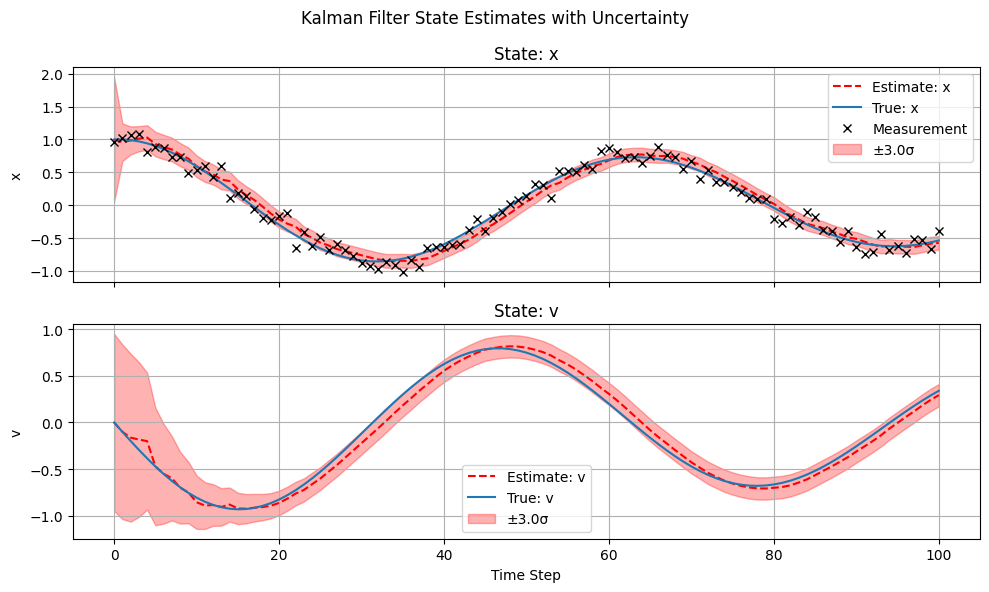

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykal.ekf import EKF
# physical parameters
k, m, c = 1.0, 1.0, 0.2
dt = 0.1

# --------------------------------------------------
# 1) Discrete‐Time System
# --------------------------------------------------
A_d = np.array([[1.0,      dt],
                [-k/m * dt, 1.0 - c/m * dt]])
B_d = np.array([[0.0],
                [    dt/m ]])
H  = lambda x,u: np.array([[1.0, 0.0]])
h  = lambda x,u: np.array([x[0]])

def f_discrete(x, u):
    x_next = A_d @ x
    if u is not None:
        # assume u is scalar or shape-(1,)
        x_next += (B_d.flatten() * float(np.atleast_1d(u)))
    return x_next

def F_discrete(x, u):
    return A_d

# instantiate discrete‐time EKF
ekf_d = EKF(
    f=f_discrete, h=h,
    Q=1e-4 * np.eye(2),       # discrete process‐noise cov
    R=np.array([[0.01]]),     # measurement‐noise cov
    dt=dt,
    system_type=pk.SystemType.DISCRETE_TIME_INVARIANT
)

# simulate zero‐input “true” trajectory
t = np.arange(0, 10+dt/2, dt)
x0 = pd.Series([1.0, 0.0], index=['x','v'])
P0 = 0.1 * np.eye(2)

x_true_d = np.zeros((len(t), 2))
x_true_d[0] = x0.values
for k in range(1, len(t)):
    x_true_d[k] = f_discrete(x_true_d[k-1], u=None)

y_d = x_true_d[:, 0] + 0.1 * np.random.randn(len(t))
y_df_d = pd.DataFrame(y_d, columns=['x'])


# run filter
x_est_d, P_est_d = ekf_d.run(x0, P0, y_df_d, F_discrete, H)

# align lengths
N = len(x_true_d)  # 101 in your example
x_est_d = x_est_d.iloc[:N]
P_est_d = P_est_d[:N]
y_df_d  = y_df_d.iloc[:N]
ekf_d.plot_kf_predictions(
    x_est_d, P_est_d,
    x_true_df=pd.DataFrame(x_true_d, columns=['x','v']),
    y_df=y_df_d
)

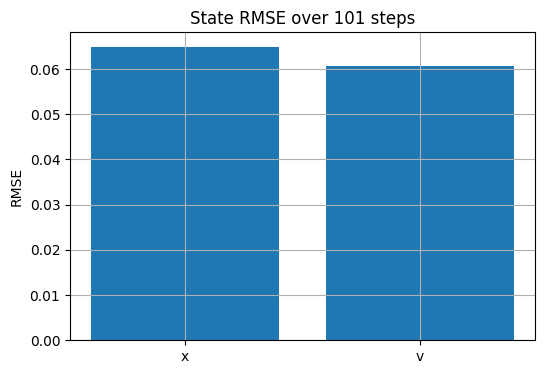

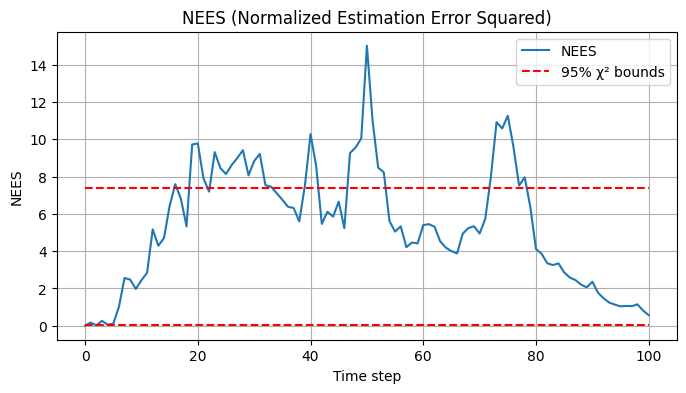

In [ ]:
ekf_d.plot_error(x_true_df=pd.DataFrame(x_true_d, columns=['x','v']),x_est_df=x_est_d,P_est=P_est_d)